# INTRODUCTION & OBJECTIVE

We are given a large dataset of Airbnb listings in Malaga, Spain, from **June 2024 - June 2025**, each listing containing **over 90 descriptive features**. 
Our goal is to understand **how prices vary across Malaga**, what affects them most, and in what way. We ask ourselves, are there any **price patterns related to date, location, room type, availability and host characteristics**? And if so, **how strong** of a relation is present?

After **understanding our data** and its meaning (descriptive *and* visual), we will create a **machine learning model**, which will predict an appropriate price for a new Airbnb listing.

### WHY?

Many Airbnb **hosts don't know** how much to charge. A predictive model can help them out, since it is based on previous similar listings, ensuring that the price is low enough to be worth the buy, but also high enough to still **attract customers** and make **profit**.

In [38]:
""" IMPORTING THE CLEANED DATA """

import numpy as np
import pandas as pd
from pathlib import Path

# Go up two levels: from documentation to PROJECT_Malaga
PROJECT_ROOT = Path.cwd().parent

# Point to the real data folder
CLEANED_PATH = PROJECT_ROOT / "data" / "listings_cleaned.csv"

# Load CSV
df = pd.read_csv(CLEANED_PATH)
print(df.shape)
df.head(3)

(8660, 52)


,id,name,description,host_id,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,...,num_amenities,is_luxury,spring_avail_rate,spring_available,summer_avail_rate,summer_available,fall_avail_rate,fall_available,winter_avail_rate,winter_available
0,96033,"Bonito piso a 200m de la playa, El Palo (Málaga)",Do you have a backpacker spirit and are lookin...,510467,Este,36.720310,-4.356270,Entire rental unit,Entire home/apt,3,...,53,False,0.706522,1,0.326087,0,0.813187,1,1.000000,1
1,166473,Perfect Location In Malaga,This apartment is rented out by the room - new...,793360,Este,36.720310,-4.361080,Private room in rental unit,Private room,1,...,21,False,0.304348,0,1.000000,1,1.000000,1,1.000000,1
2,330760,Malaga Lodge Guesthouse Double room-shared bath.,The Lodge is set in a charming town house in L...,1687526,Centro,36.729786,-4.413462,Private room in townhouse,Private room,2,...,56,False,0.250000,0,0.826087,1,0.967033,1,0.344444,0


## Data exploration, overview (EDA)

Let's get a grasp of statistics, data types in the dataframe, and check for any remaining missing values (test check if everything is ready).

In [39]:
id_columns = ['id', 'host_id']

numeric_df = df.select_dtypes(include=['number']).drop(columns=id_columns, errors='ignore')

# Calculate mean, min, max
stats_df = pd.DataFrame({
    'mean': numeric_df.mean(),
    'min': numeric_df.min(),
    'max': numeric_df.max()
})

stats_df = stats_df.round(2)

# --> print("Statistic overview:")
# --> print(stats_df)

# --> print("Basic info: \n")
# --> print(df.info())

The above statistic/dtype overview is too heavy to comprehend all at once, so we won't even show it, and will rather analyze features individually to gain better understanding of the data.

In [40]:
# See how many missing values each column has
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

print(missing_summary)

Series([], dtype: int64)


^^^ Implies we have successfully replaced all missing values, as well as tells us a bit about the structure of the DataFrame (not in-depth).

## Univariate analysis

Let's now explore some of the more important features, **individually**. For now, we are interested in **price** (the target), **categorical variables** (room type, property type, host), and **availability** (including seasonal).

### Price distribution

Since there are a few outliars on the high-end of price charts (extreme luxury), it is worth looking at **log-transformed plots**, to handle **skewness**. We will also look at a violin plot, where **luxury** listing are **left out** manually.

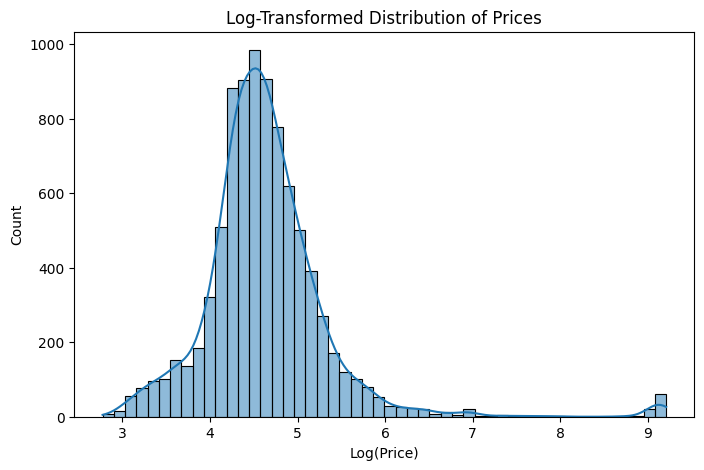

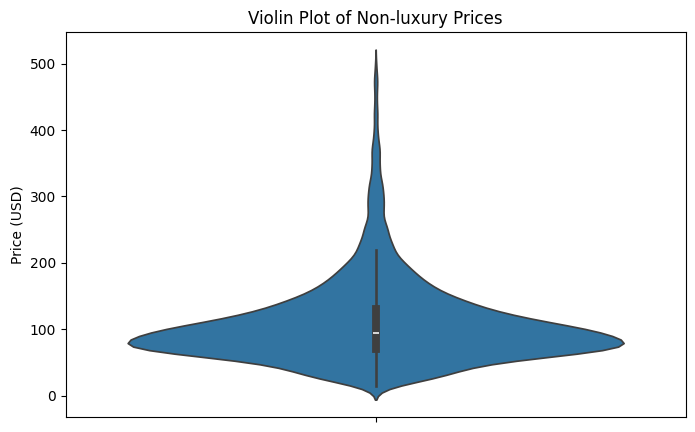

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Log-transformed histogram of Price
plt.figure(figsize=(8,5))
sns.histplot(df['price'].apply(lambda x: np.log1p(x)), bins=50, kde=True)
plt.title("Log-Transformed Distribution of Prices")
plt.xlabel("Log(Price)")
plt.ylabel("Count")
plt.show()

# Violin Plot for Price Distribution, non-luxury
plt.figure(figsize=(8,5))
sns.violinplot(y=df[df['is_luxury'] == False]['price'])
plt.title("Violin Plot of Non-luxury Prices")
plt.ylabel("Price (USD)")
plt.show()

Clearly, the large majority of listings are below 400 USD, mostly in the 20 - 200 range.

### Distribution of categorical variables

Our priorities are room type, property type, and information about the host.

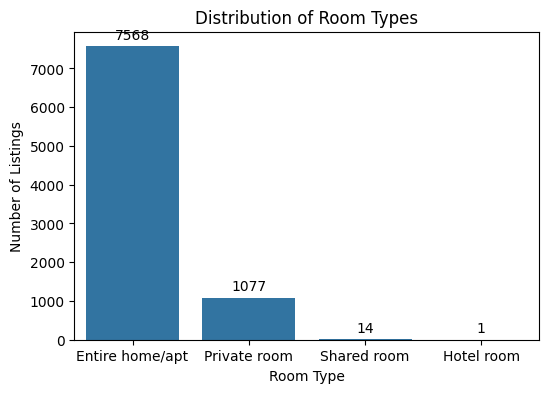

In [42]:
# Room type

plt.figure(figsize=(6,4))
ax = sns.countplot(
    data=df, 
    x='room_type', 
    order=df['room_type'].value_counts().index
)

plt.title("Distribution of Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

# Add counts above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, color='black', xytext=(0,3),
                textcoords='offset points')

plt.show()


Since we will be doing prediction modeling later on, it is worth noting that Shared room and Hotel room samples will be discarded, since they only represent 15 samples of the data and introduce unnecessary variance. We will keep them for now though.

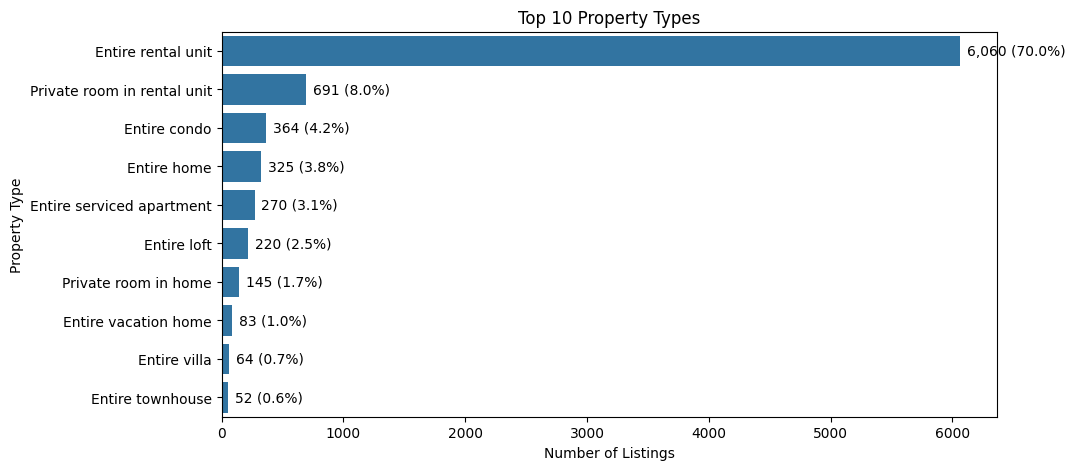

In [43]:
# Property type
plt.figure(figsize=(10,5))

top_props = df['property_type'].value_counts().nlargest(10)
prop_order = top_props.index
total = len(df)

ax = sns.countplot(
    data=df[df['property_type'].isin(prop_order)], 
    y='property_type', 
    order=prop_order
)

plt.title("Top 10 Property Types")
plt.xlabel("Number of Listings")
plt.ylabel("Property Type")

for p in ax.patches:
    count = p.get_width()
    percent = 100 * count / total
    ax.annotate(f'{int(count):,} ({percent:.1f}%)',
                (count, p.get_y() + p.get_height()/2),
                ha='left', va='center',
                fontsize=10, color='black', xytext=(5,0),
                textcoords='offset points')

plt.show()


As expected, the majority of listings are designated rental units, but we can still extract valuable info out of the other categories.

It makes sense the low number of Entire villa and (maybe) Entire vacation home has a direct correlation to luxury prices, implying we keep that in mind for later analysis.

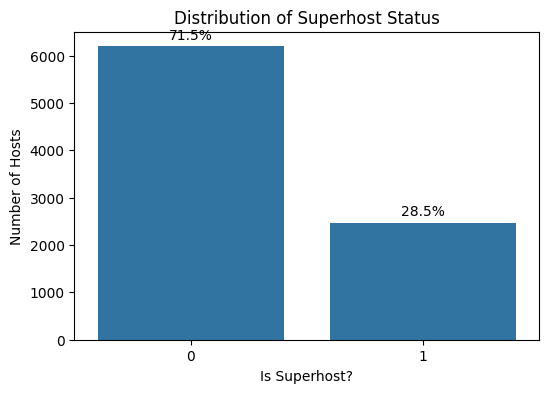

In [44]:
# Host superhost status

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='host_is_superhost')

plt.title("Distribution of Superhost Status")
plt.xlabel("Is Superhost?")
plt.ylabel("Number of Hosts")

total = len(df)

for p in ax.patches:
    count = p.get_height()
    percent = 100 * count / total
    ax.annotate(f'{percent:.1f}%',   # e.g. 34.2%
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom',
                fontsize=10, color='black', xytext=(0,3),
                textcoords='offset points')

plt.show()

Just to clarify, a Superhost is a status given to a host with outstanding hospitality by Airbnb. For guests, this obviously signals a **high-quality** experience. We will analyze the effects of superhost status in bivariate analysis.

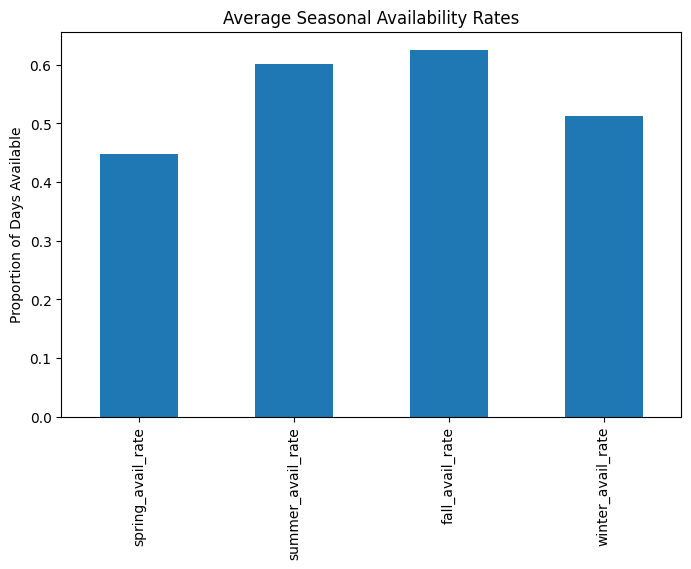

In [45]:
# Seasonal availability status

season_rates = ['spring_avail_rate','summer_avail_rate','fall_avail_rate','winter_avail_rate']

plt.figure(figsize=(8,5))
df[season_rates].mean().plot(kind='bar')
plt.title("Average Seasonal Availability Rates")
plt.ylabel("Proportion of Days Available")
plt.show()


We see about 20% higher availability in summer and fall (the travel seasons). This tells us a few things:
    - Summer and fall seem to be peak travel seasons for Malaga (expected)
    - Hosts might block off winter/spring for personal use (ex. vacation homes)
    - More supply in peak seasons means more competition for hosts, but since there is also high demand, prices might still stay strong. This *could* result in higher revenue.

## Bivariate & Multivariate analysis

Now that we understand features individually, let's explore their **correlation with price** and eachother. This can be thought of as a human understanding for how features affect price, which will be perfected and modeled later on with machine learning.  

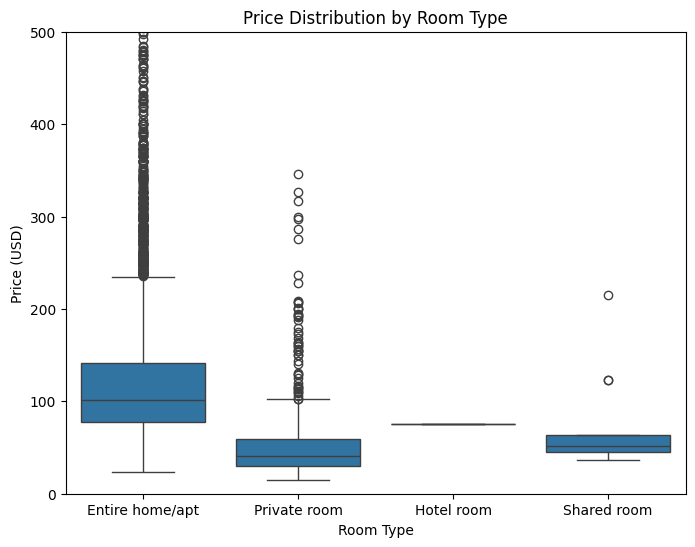

In [46]:
# Price vs. Room type

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='room_type',
    y='price'
)
plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price (USD)")
plt.ylim(0, 500)  # cap y-axis to remove extreme outliers
plt.show()

^^^ Recall from earlier that there is only 1 Hotel room and only 14 Shared rooms in our data, so those aren't crucial.
As expected, we see that prices for Entire homes/apts are significantly bigger than for singular rooms, with Private rooms *almost* never reaching over 200 USD. 

### Host analysis

Since one of our final goals is to help new hosts predict prices for their own listings, let's see if **price** has any **correlation** with their experience, reviews, response rate ... 

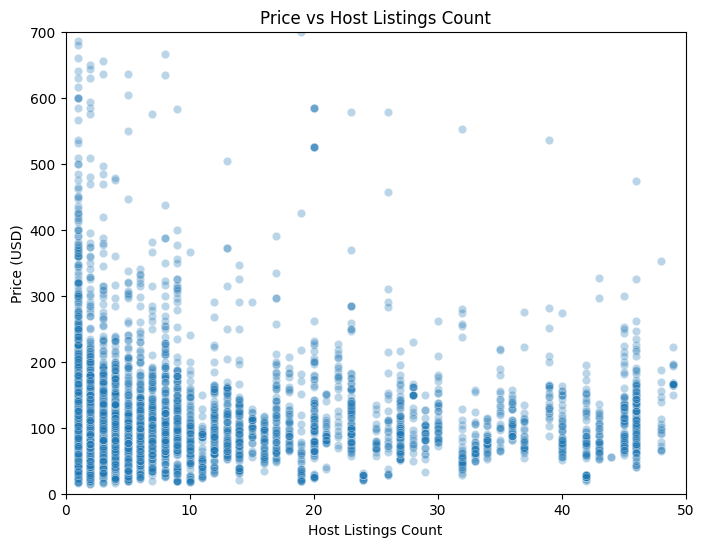

In [47]:
# 1. Number of listings

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, 
    x='host_listings_count', 
    y='price', 
    alpha=0.3
)
plt.title("Price vs Host Listings Count")
plt.xlabel("Host Listings Count")
plt.ylabel("Price (USD)")
plt.ylim(0, 700)  # trim outliers for clarity
plt.xlim(0, 50)    # zoom in (optional)
plt.show()


^^^ It seems that hosts with more listings tend to have cheaper prices on average, but this *could* only be an illusion, since there are probably many more hosts with less listings, making the left side more crowded. Let's check to **make sure**:

Number of hosts with less than 10 listings: 4791
Number of hosts with more than 10 listings: 3869


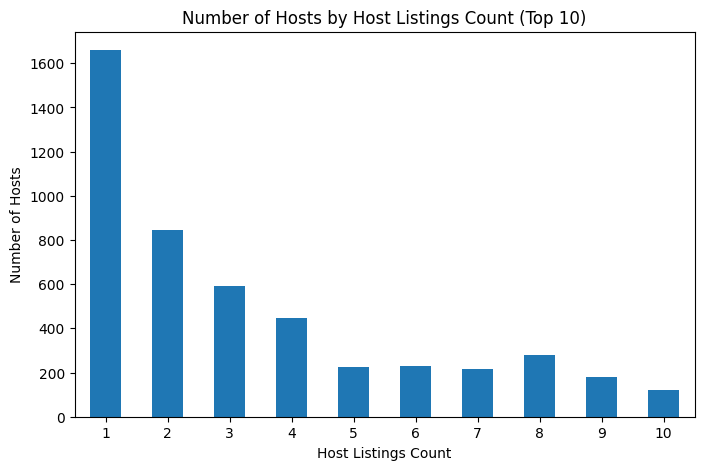

In [48]:
print(f"Number of hosts with less than 10 listings: {len(df[df['host_listings_count'] <= 10])}")
print(f"Number of hosts with more than 10 listings: {len(df[df['host_listings_count'] > 10])}")

counts = df.groupby('host_listings_count')['host_listings_count'].count().head(10)

plt.figure(figsize=(8,5))
counts.plot(kind='bar')

plt.title("Number of Hosts by Host Listings Count (Top 10)")
plt.xlabel("Host Listings Count")
plt.ylabel("Number of Hosts")
plt.xticks(rotation=0)
plt.show()

Since we now know the left side of the scatter plot was much more crowded, it doesn't tell us much. Let's keep exploring.

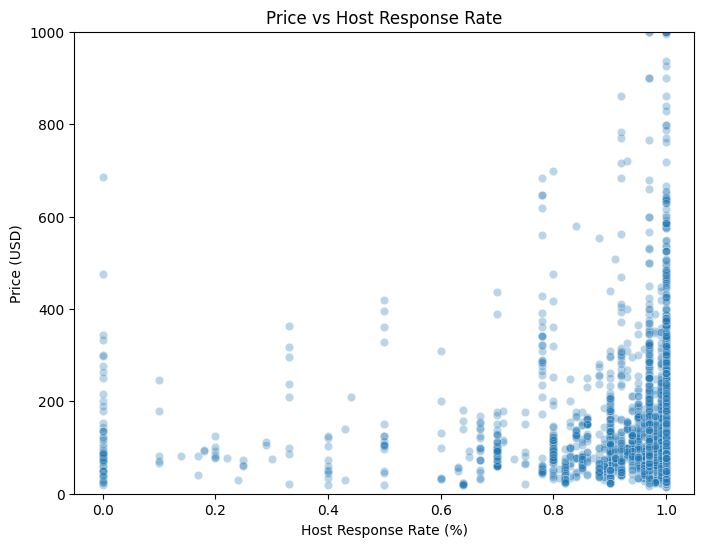

In [49]:
# 2. Host Response rate

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='host_response_rate',
    y='price',
    alpha=0.3
)
plt.title("Price vs Host Response Rate")
plt.xlabel("Host Response Rate (%)")
plt.ylabel("Price (USD)")
plt.ylim(0, 1000)
plt.show()


^^^ Although the chart is crowded again, we can see that almost no hosts with a low response rate have prices over 200 USD. This implies, if you're a host that's setting a higher price, you **must** be responsive. 

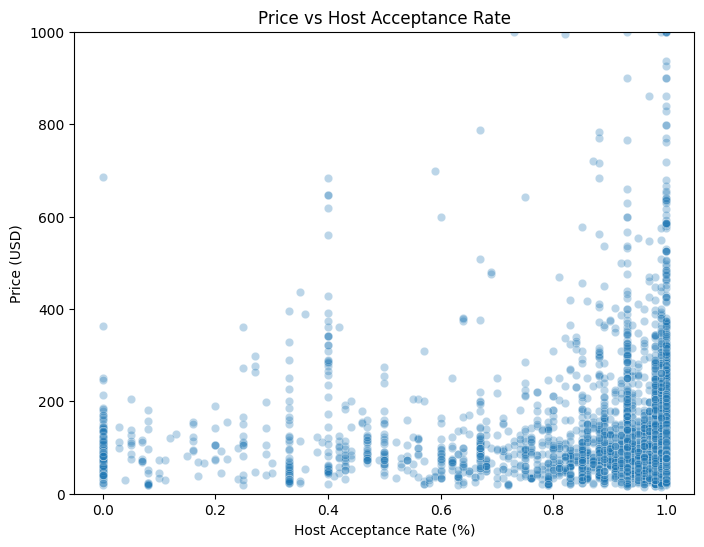

In [50]:
# 3. Host acceptance rate

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='host_acceptance_rate',
    y='price',
    alpha=0.3
)
plt.title("Price vs Host Acceptance Rate")
plt.xlabel("Host Acceptance Rate (%)")
plt.ylabel("Price (USD)")
plt.ylim(0, 1000)
plt.show()

^^^ Our data is crowded towards high acceptance rate, with no obvious/visible patterns. We can't extract anything useful from this, but it was still worth checking.

## Location analysis

Now, let's look at how location affects price, as it should have an obvious impact. The available data we have are the **coordinates**, as well as the **neighbourhood name**.

### Neighbourhood

   neighbourhood_cleansed  all_mean_price  nonluxury_mean_price luxury_share
0             Campanillas      965.593750            154.137931        9.38%
1               Churriana      678.682759            131.835938       11.72%
2      Puerto de la Torre      402.558140            114.315789       11.63%
3                    Este      354.044864            119.374690        4.84%
4    Teatinos-Universidad      241.681818            109.047059        3.41%
5      Carretera de Cadiz      230.704784             98.691211        1.75%
6     Cruz De Humilladero      225.577830             93.884615        1.89%
7       Bailen-Miraflores      220.390152             72.382239        1.89%
8                  Centro      168.123609            112.019452        1.69%
9          Palma-Palmilla      167.933333             94.962121        2.22%
10          Ciudad Jardin      111.082192             97.042254        2.74%


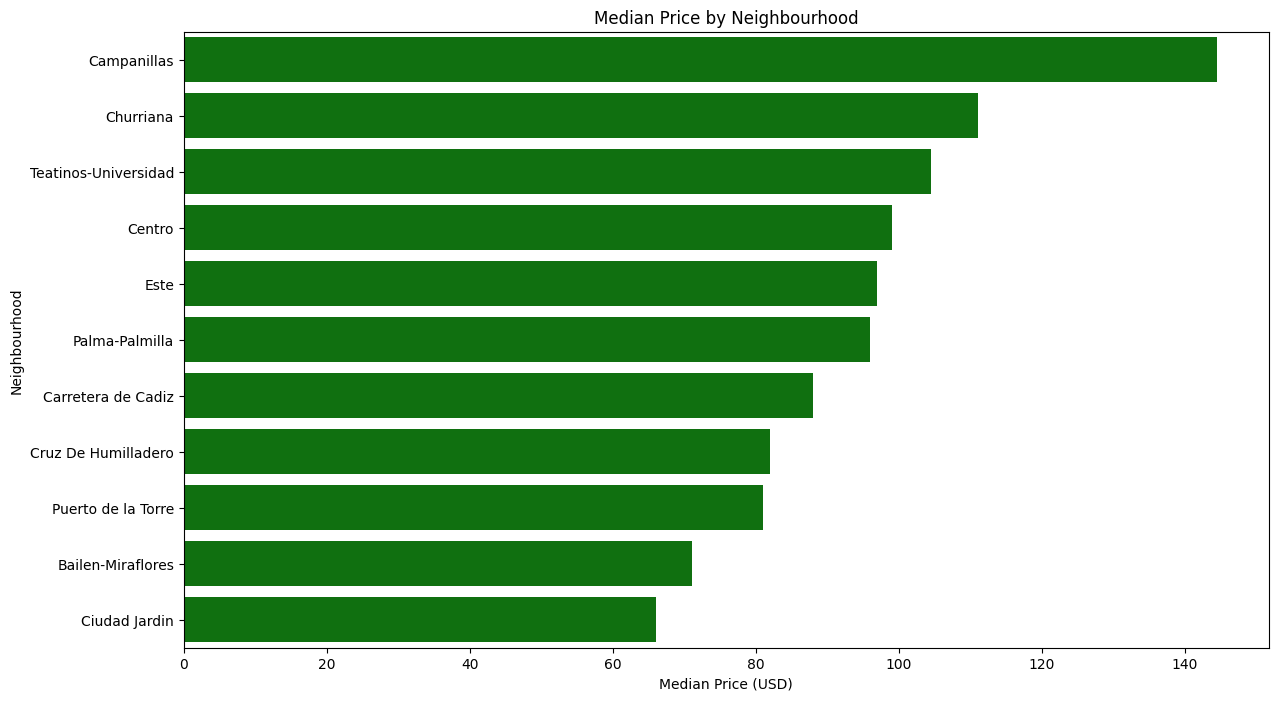

In [51]:
hood_mean_1 = (
    df[df['is_luxury'] == 0]
    .groupby('neighbourhood_cleansed')['price']
    .mean()
    .rename("nonluxury_mean_price")
)

hood_mean_2 = (
    df.groupby('neighbourhood_cleansed')['price']
    .mean()
    .rename("all_mean_price")
)

luxury_share = (
    df.groupby('neighbourhood_cleansed')['is_luxury']
    .mean()
    .apply(lambda x: f"{x*100:.2f}%")
    .rename("luxury_share")
)

hood_compare = pd.concat([hood_mean_2, hood_mean_1, luxury_share], axis=1).sort_values(by="all_mean_price", ascending=False).reset_index()
print(hood_compare)

plt.figure(figsize=(14,8))
avg_prices = df.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False)
sns.barplot(
    x=avg_prices.values,
    y=avg_prices.index,
    color="green"
)
plt.title("Median Price by Neighbourhood")
plt.xlabel("Median Price (USD)")
plt.ylabel("Neighbourhood")
plt.show()


^^^ The table represents the neighbourhoods average price (mean), while the chart looks at its median price. We look at **both** just in case, since mean is sensitive to outliars (hence the extra column), but median almost ignores them.

We can see that **Campanillas and Churriana** are the **most luxurious** on average, with Campanillas clearly above everyone else.
Beside those, we see a big proportion of luxury is also in Puerto de la Torre, hence it taking 3rd place on the table, but it sits relatively low on our median bar chart. This implies a high price variance there, containing lots of luxury, but also lots of below (mean) average pricing.

### Coordinates (Latitude & Longitude)

First, let's get an idea of where on the map our listings are located
(NOTE: Malaga is located on the south-east beach of Spain, see **file in visuals** for **interactive view** (blue dots are top 15 locations))

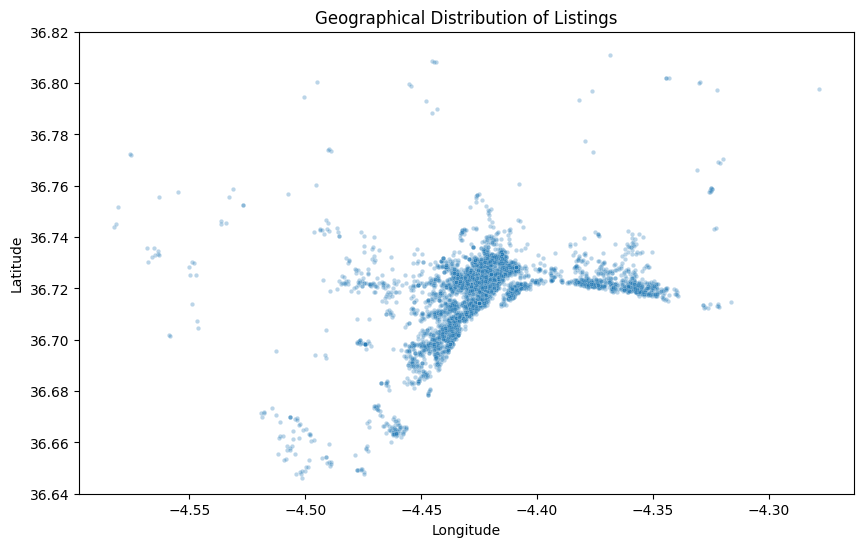

In [52]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df, 
    x="longitude", 
    y="latitude", 
    alpha=0.3, 
    s=10
)
plt.title("Geographical Distribution of Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.ylim(36.64, 36.82)
plt.show()

Now let's color areas by average price.

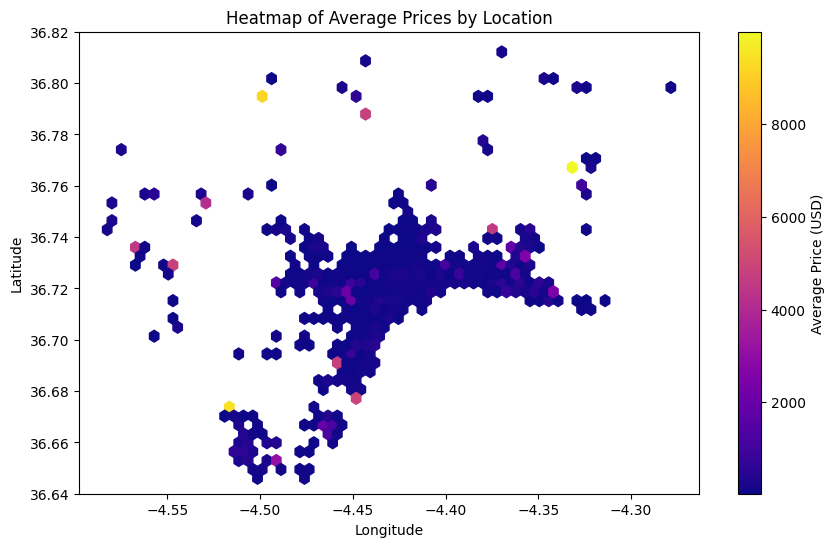

In [53]:
plt.figure(figsize=(10,6))
hb = plt.hexbin(
    df['longitude'], 
    df['latitude'], 
    C=df['price'], 
    gridsize=60, 
    cmap="plasma", 
    reduce_C_function=np.mean
)
plt.colorbar(hb, label="Average Price (USD)")
plt.title("Heatmap of Average Prices by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.ylim(36.64, 36.82)
plt.show()

We can see **2 small clumps** of higher pricing. The first is along the east side of the shore (ESTE), and the second is left of the center of the map (CRUZ DE HUMILLADERO), stretching out even further to the left (CAMPANILLAS).
The **villas** (yellow) seem to be in quite **random** locations, as expected.

Since we don't see any more useful patterns, further geospatial analysis with other tools (geopandas, folium) isn't needed.

## Modeling

Continiue onto the machine_learning notebook in the same folder.

## Summary

We've analyzed Airbnb listings in Málaga to understand **how nightly prices vary** and **what factors** influence them the most. Through **descriptive statistics and visualizations**, we explored location, property type, availability, host characteristics, and review scores. We identified clear geographic patterns, such as higher average prices in Campanillas and Churriana compared to e.g. Centro. Property type, host engagement, and seasonal availability also played important roles in price differences.

Building on these insights, we will now aim for a **optimized amachine learning model** that predicts the nightly price of a listing. Importantly, the model creation will allows us to quantify how much each feature contributes to pricing and provide practical guidance for new hosts (*open* machine_learning).

### Post-model creation:
The final model, an XGBoost pipeline with tuned hyperparameters, achieved **strong predictive performance** with a *reasonable* margin for error.

**Overall**, this analysis intuitivelly **demonstrates how data-driven approaches** can **improve transparency** in **Airbnb markets**, support **host decision-making**, and highlight the underlying dynamics of short-term rental pricing in Málaga.